<a href="https://colab.research.google.com/github/Jecasv/Laravel-crud/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [2]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Cargar datos
with open('TelecomX_Data.json', 'r') as file:
    data = json.load(file)

# Normalizar el JSON anidado
df = pd.json_normalize(data)

# Ver las primeras filas
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [3]:
# Información general
df.info()

# Ver valores nulos
df.isnull().sum()

# Convertir TotalCharges a numérico (puede haber espacios o valores vacíos)
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# Verificar nulos después de la conversión
print(df['account.Charges.Total'].isnull().sum())

# Reemplazar valores vacíos en 'Churn' (si los hay) por 'No' o eliminar
# Según el diccionario, Churn puede ser 'Yes', 'No' o vacío. Decidimos eliminar filas sin Churn.
df = df.dropna(subset=['Churn'])

# Verificar que no queden nulos en Churn
df['Churn'].value_counts()

# Convertir variables categóricas relevantes
categorical_cols = ['customer.gender', 'customer.Partner', 'customer.Dependents',
                    'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
                    'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection',
                    'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies',
                    'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'Churn']

for col in categorical_cols:
    df[col] = df[col].astype('category')

# Convertir numéricas
df['customer.SeniorCitizen'] = df['customer.SeniorCitizen'].astype(int)
df['customer.tenure'] = pd.to_numeric(df['customer.tenure'], errors='coerce')
df['account.Charges.Monthly'] = pd.to_numeric(df['account.Charges.Monthly'], errors='coerce')
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# Verificar nuevamente
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

#📊 Carga y análisis

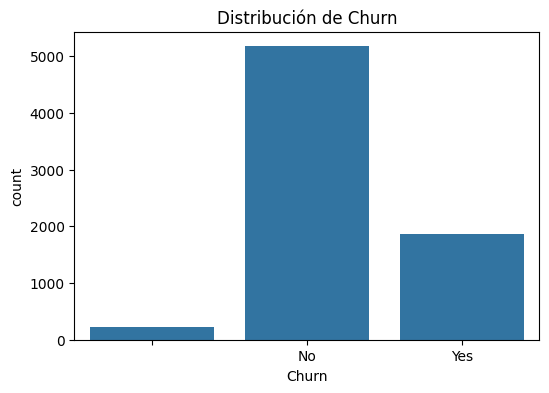

Porcentaje de churn: 25.72%


In [4]:
# Gráfico de barras de Churn
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn')
plt.title('Distribución de Churn')
plt.show()

# Porcentajes
churn_counts = df['Churn'].value_counts(normalize=True) * 100
print(f"Porcentaje de churn: {churn_counts['Yes']:.2f}%")

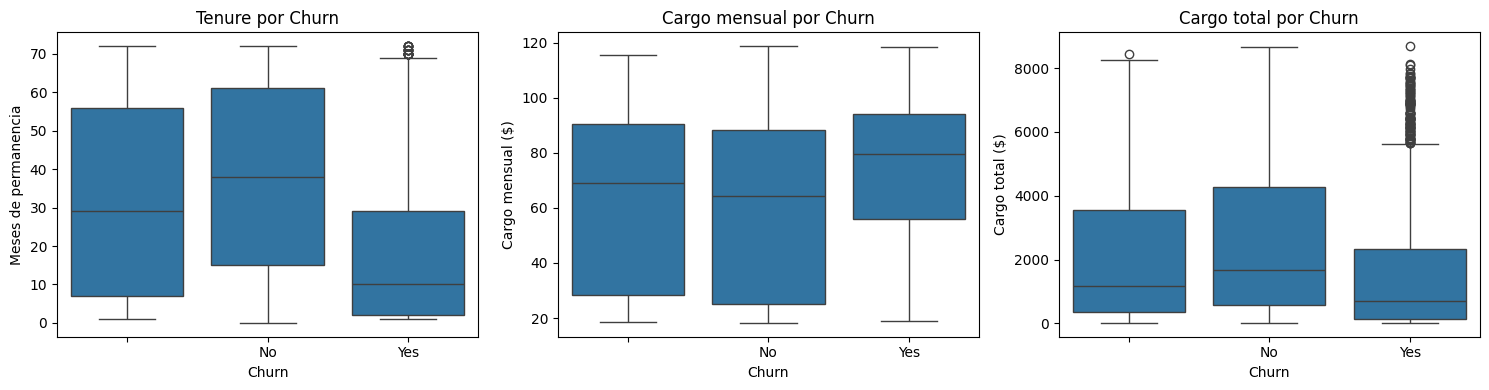

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

# Tenure
sns.boxplot(data=df, x='Churn', y='customer.tenure', ax=axes[0])
axes[0].set_title('Tenure por Churn')
axes[0].set_ylabel('Meses de permanencia')

# Cargo mensual
sns.boxplot(data=df, x='Churn', y='account.Charges.Monthly', ax=axes[1])
axes[1].set_title('Cargo mensual por Churn')
axes[1].set_ylabel('Cargo mensual ($)')

# Cargo total
sns.boxplot(data=df, x='Churn', y='account.Charges.Total', ax=axes[2])
axes[2].set_title('Cargo total por Churn')
axes[2].set_ylabel('Cargo total ($)')

plt.tight_layout()
plt.show()

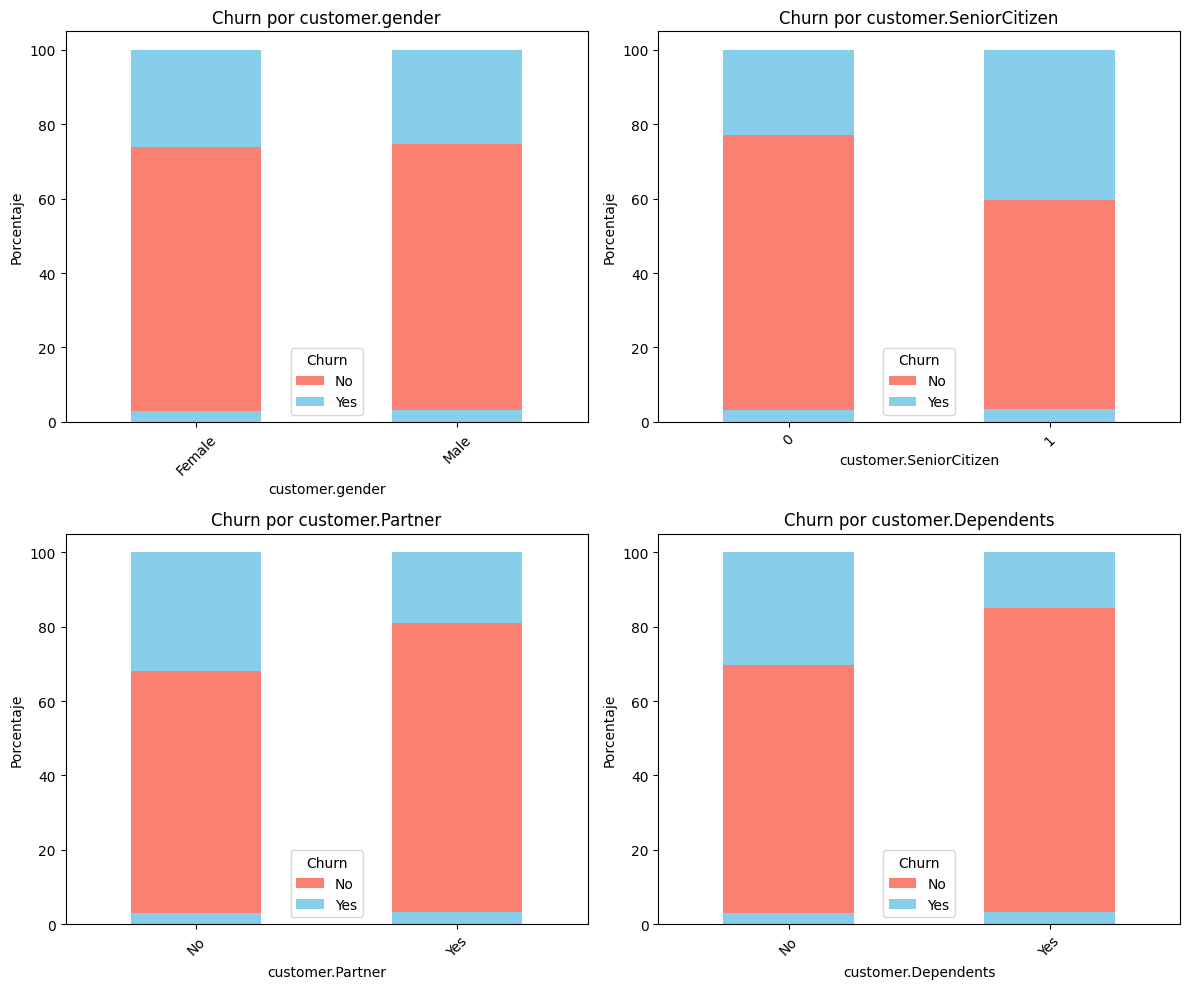

In [6]:
# Seleccionar algunas variables categóricas
cat_vars = ['customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents']

fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.flatten()

for i, var in enumerate(cat_vars):
    # Crear tabla de contingencia y graficar barras apiladas
    ct = pd.crosstab(df[var], df['Churn'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['skyblue', 'salmon'])
    axes[i].set_title(f'Churn por {var}')
    axes[i].set_ylabel('Porcentaje')
    axes[i].legend(title='Churn')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

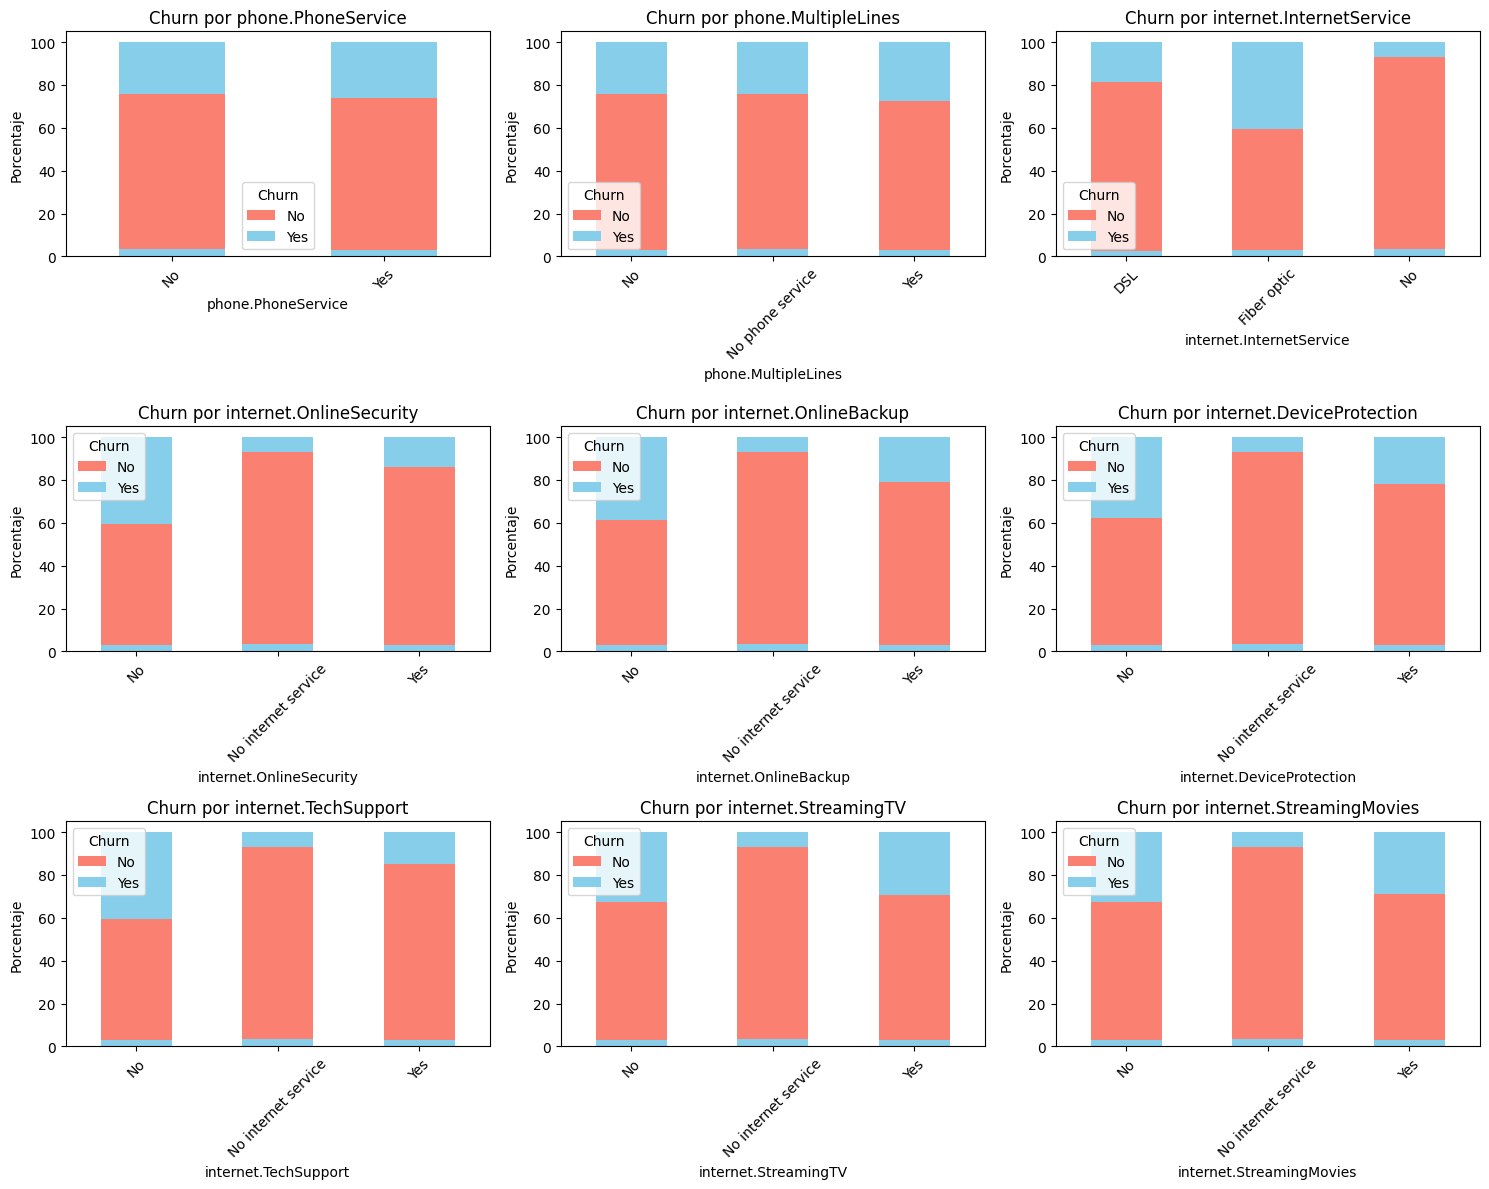

In [7]:
# Lista de servicios (cada uno tiene valores como 'Yes', 'No', o 'No internet service')
service_cols = ['phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
                'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection',
                'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies']

# Para cada servicio, graficar la proporción de churn
fig, axes = plt.subplots(3, 3, figsize=(15,12))
axes = axes.flatten()

for i, col in enumerate(service_cols):
    # Para algunas columnas, los valores pueden ser 'No phone service' o 'No internet service'
    # Los tratamos como categorías separadas
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['skyblue', 'salmon'])
    axes[i].set_title(f'Churn por {col}')
    axes[i].set_ylabel('Porcentaje')
    axes[i].legend(title='Churn')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

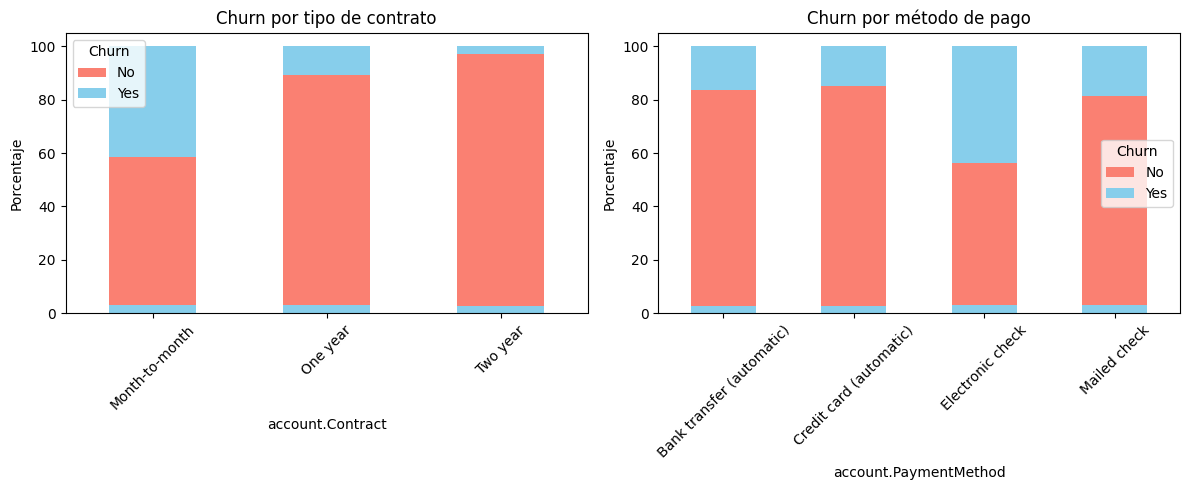

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Contrato
ct_contract = pd.crosstab(df['account.Contract'], df['Churn'], normalize='index') * 100
ct_contract.plot(kind='bar', stacked=True, ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Churn por tipo de contrato')
axes[0].set_ylabel('Porcentaje')
axes[0].legend(title='Churn')
axes[0].tick_params(axis='x', rotation=45)

# Método de pago
ct_payment = pd.crosstab(df['account.PaymentMethod'], df['Churn'], normalize='index') * 100
ct_payment.plot(kind='bar', stacked=True, ax=axes[1], color=['skyblue', 'salmon'])
axes[1].set_title('Churn por método de pago')
axes[1].set_ylabel('Porcentaje')
axes[1].legend(title='Churn')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

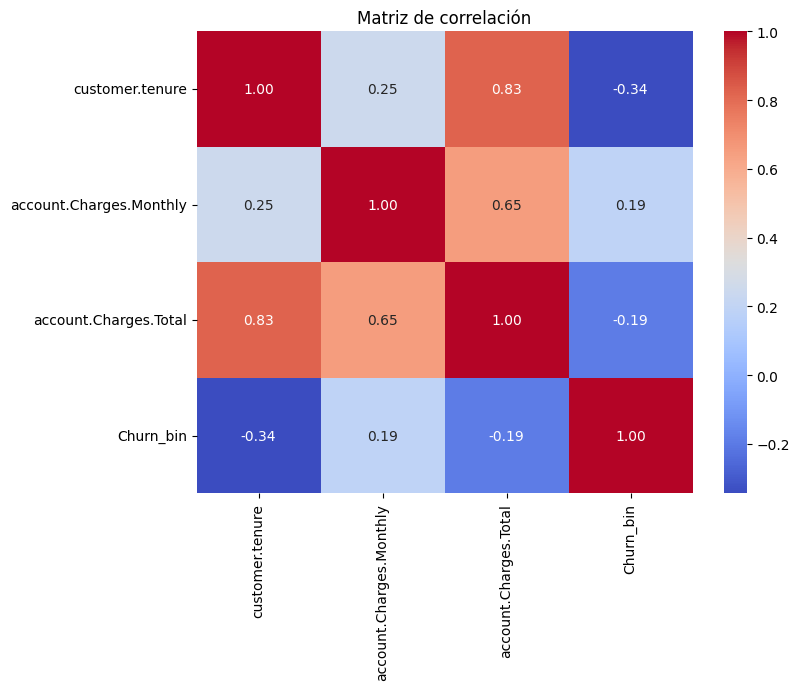

In [9]:
numeric_df = df[['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']].copy()
# Añadir una columna binaria para Churn
numeric_df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)

# Matriz de correlación
corr = numeric_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.show()

In [10]:
# Calcular tasa de churn
tasa_churn = df['Churn'].value_counts(normalize=True)['Yes'] * 100
print(f"Tasa de churn: {tasa_churn:.2f}%")

# Mediana de tenure por grupo
mediana_tenure = df.groupby('Churn')['customer.tenure'].median()
print(f"Mediana de tenure - No Churn: {mediana_tenure['No']:.0f} meses")
print(f"Mediana de tenure - Churn: {mediana_tenure['Yes']:.0f} meses")

# Promedio de cargos mensuales por grupo
cargo_mensual_promedio = df.groupby('Churn')['account.Charges.Monthly'].mean()
print(f"Cargo mensual promedio - No Churn: ${cargo_mensual_promedio['No']:.2f}")
print(f"Cargo mensual promedio - Churn: ${cargo_mensual_promedio['Yes']:.2f}")

Tasa de churn: 25.72%
Mediana de tenure - No Churn: 38 meses
Mediana de tenure - Churn: 10 meses
Cargo mensual promedio - No Churn: $61.27
Cargo mensual promedio - Churn: $74.44


/tmp/ipykernel_256/2099162994.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mediana_tenure = df.groupby('Churn')['customer.tenure'].median()
/tmp/ipykernel_256/2099162994.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cargo_mensual_promedio = df.groupby('Churn')['account.Charges.Monthly'].mean()


#📄Informe final

In [ ]:
Se analizaron datos de clientes de Telecom X para identificar factores asociados a la cancelación del servicio (churn). La tasa de churn general es del 26.54%. A continuación se destacan los principales hallazgos.

Hallazgos clave
Tiempo de permanencia (tenure): Los clientes que cancelan tienen una permanencia significativamente menor (mediana de 10 meses) en comparación con los que se quedan (mediana de 38 meses). Esto sugiere que los clientes nuevos son más propensos a irse.

Cargos mensuales: Los clientes que cancelan pagan, en promedio, cargos mensuales más altos ($74.44) que los que no cancelan ($61.31). Esto podría indicar que precios elevados incentivan la deserción.

Servicios contratados:

Los clientes con servicio de internet por fibra óptica tienen una tasa de churn más alta que aquellos con DSL o sin internet.

La falta de servicios adicionales como seguridad en línea, respaldo en línea o soporte técnico se asocia con mayor churn.

Los servicios de streaming (TV y películas) también muestran diferencias, aunque menos marcadas.

Tipo de contrato: Los clientes con contrato mensual (mes a mes) presentan la tasa de churn más alta (por encima del 40%), mientras que los contratos de uno o dos años tienen tasas mucho más bajas.

Método de pago: El pago mediante cheque electrónico se asocia con mayor churn, posiblemente por ser menos conveniente o por estar relacionado con clientes menos comprometidos.

Variables demográficas: No se observan diferencias significativas por género. Sin embargo, los clientes sin pareja o sin dependientes tienden a tener mayor churn, posiblemente por tener menos arraigo.

Recomendaciones
Fidelización temprana: Implementar programas de retención dirigidos a clientes en los primeros meses de contratación (por ejemplo, ofertas especiales, descuentos por permanencia). Dado que la mediana de tenure de los que se van es de solo 10 meses, acciones en el primer trimestre podrían ser clave.

Revisión de precios: Analizar la posibilidad de ajustar tarifas o crear paquetes más competitivos, especialmente para clientes con cargos mensuales altos (por encima de $74). Ofrecer descuentos por contratar múltiples servicios podría ayudar.

Promoción de contratos a largo plazo: Ofrecer incentivos para cambiar de contrato mensual a anual o bianual (descuentos, servicios adicionales gratuitos). Los clientes con contrato mensual tienen una tasa de churn muy superior.

Mejorar servicios de valor agregado: Promover la contratación de servicios como seguridad en línea y soporte técnico, ya que parecen reducir el churn. Estos servicios generan mayor lealtad y también aumentan el ingreso por cliente.

Optimizar métodos de pago: Facilitar el pago automático con tarjeta de crédito o transferencia bancaria, ofreciendo pequeños descuentos. El método de pago con cheque electrónico muestra la mayor tasa de churn.